In [1]:
import zipfile
with zipfile.ZipFile('/content/archive (3).zip','r') as z:
  z.extractall('/content/')
  print(z.namelist())

['CAR DETAILS FROM CAR DEKHO.csv', 'Car details v3.csv', 'car data.csv', 'car details v4.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Dataset

In [3]:
df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
df.head()

Shape: (4340, 8)

Data types:
 name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## 2. Data Cleaning

In [5]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)

Missing values:
 name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate rows: 763

Data types:
 name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object


In [6]:
# Confirm no case/spelling inconsistencies (e.g., "Petrol" vs "petrol") in categorical columns
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
    print(f"{col}: {df[col].unique()}")

fuel: ['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']
seller_type: ['Individual' 'Dealer' 'Trustmark Dealer']
transmission: ['Manual' 'Automatic']
owner: ['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


**Observation:** No missing values or duplicate rows were found. All categorical columns (`fuel`, `seller_type`, `transmission`, `owner`) use consistent formatting with no case or spelling mismatches, so no correction was necessary.

## 3. Feature Engineering

In [7]:
current_year = 2020
df['car_age'] = current_year - df['year']
df['brand'] = df['name'].apply(lambda x: x.split()[0])

print("Unique brands:", df['brand'].nunique())
df[['name', 'brand', 'year', 'car_age']].head()

Unique brands: 29


,name,brand,year,car_age
0,Maruti 800 AC,Maruti,2007,13
1,Maruti Wagon R LXI Minor,Maruti,2007,13
2,Hyundai Verna 1.6 SX,Hyundai,2012,8
3,Datsun RediGO T Option,Datsun,2017,3
4,Honda Amaze VX i-DTEC,Honda,2014,6


In [8]:
df_clean = df.drop(columns=['name', 'year'])
df_clean.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand
0,60000,70000,Petrol,Individual,Manual,First Owner,13,Maruti
1,135000,50000,Petrol,Individual,Manual,First Owner,13,Maruti
2,600000,100000,Diesel,Individual,Manual,First Owner,8,Hyundai
3,250000,46000,Petrol,Individual,Manual,First Owner,3,Datsun
4,450000,141000,Diesel,Individual,Manual,Second Owner,6,Honda


## 4. Exploratory Data Analysis (EDA)

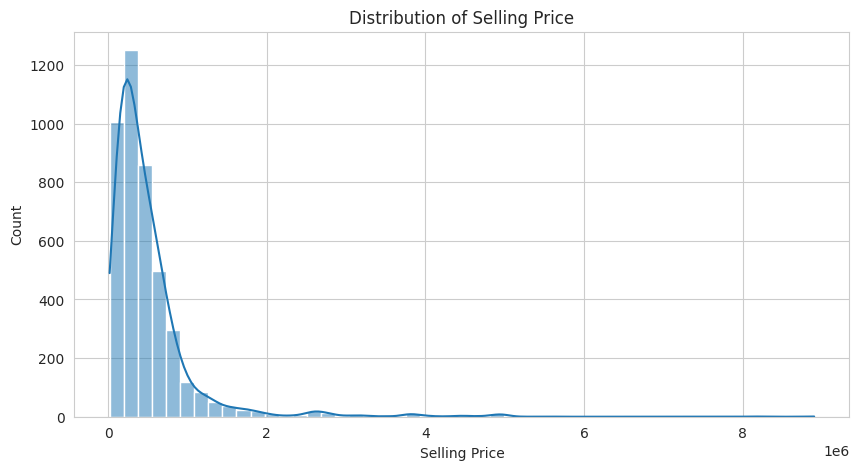

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['selling_price'], bins=50, kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.show()

**Observation:** Selling price is right-skewed — most cars are priced under ₹500,000, with a long tail of higher-priced vehicles pulling the mean above the median.

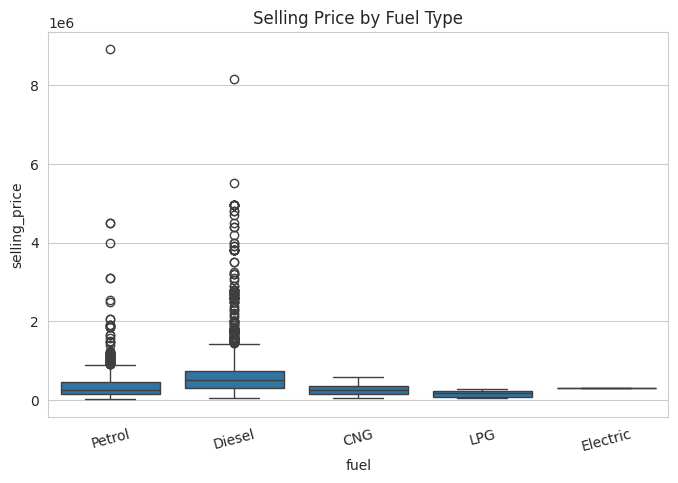

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='fuel', y='selling_price')
plt.title('Selling Price by Fuel Type')
plt.xticks(rotation=15)
plt.show()

**Observation:** Diesel cars tend to have higher median selling prices than Petrol cars, likely reflecting their association with larger, higher-end vehicles.

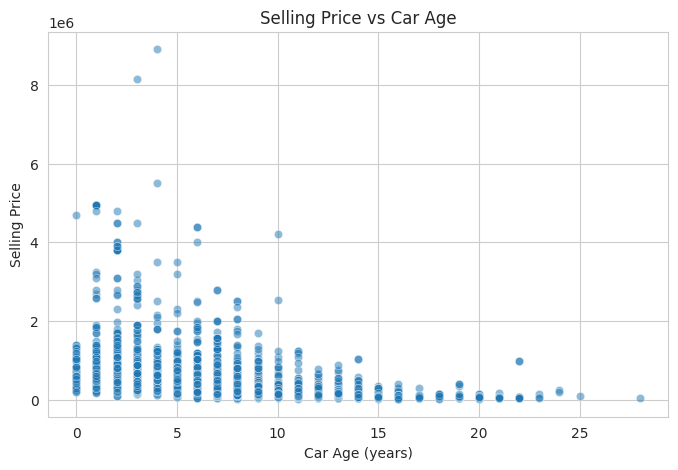

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='car_age', y='selling_price', alpha=0.5)
plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (years)')
plt.ylabel('Selling Price')
plt.show()

**Observation:** Selling price decreases as car age increases, consistent with normal depreciation. The relationship is non-linear, dropping sharply in the first few years and levelling off for older cars.

## 5. Encoding Categorical Variables

In [12]:
df_encoded = pd.get_dummies(df_clean, columns=['fuel', 'seller_type', 'transmission', 'owner', 'brand'], drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (4340, 42)


,selling_price,km_driven,car_age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_OpelCorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,60000,70000,13,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
1,135000,50000,13,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,600000,100000,8,True,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
3,250000,46000,3,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
4,450000,141000,6,True,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False


## 6. Feature Correlation Heatmap

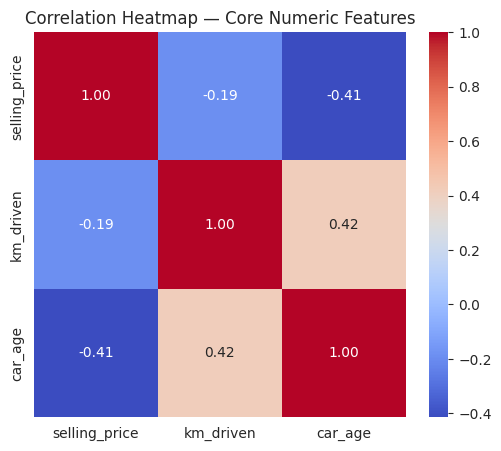


Top correlated features with selling_price:
selling_price                   1.000000
brand_BMW                       0.401857
brand_Mercedes-Benz             0.354215
brand_Audi                      0.292174
fuel_Diesel                     0.282947
brand_Land                      0.182329
brand_Toyota                    0.162161
seller_type_Trustmark Dealer    0.110176
brand_Volvo                     0.107745
brand_Jaguar                    0.100662
Name: selling_price, dtype: float64

Bottom correlated features with selling_price:
brand_Chevrolet          -0.098361
owner_Third Owner        -0.111326
brand_Tata               -0.114574
owner_Second Owner       -0.161986
brand_Maruti             -0.180798
km_driven                -0.192289
seller_type_Individual   -0.236798
fuel_Petrol              -0.269453
car_age                  -0.413922
transmission_Manual      -0.530205
Name: selling_price, dtype: float64


In [13]:
# Use only numeric, non-encoded columns plus target for a readable heatmap
corr_cols = ['selling_price', 'km_driven', 'car_age']
plt.figure(figsize=(6, 5))
sns.heatmap(df_encoded[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — Core Numeric Features')
plt.show()

# Also show correlation of every encoded feature against price, for full transparency
corr_with_price = df_encoded.corr()['selling_price'].sort_values(ascending=False)
print("\nTop correlated features with selling_price:")
print(corr_with_price.head(10))
print("\nBottom correlated features with selling_price:")
print(corr_with_price.tail(10))

## 7. Train/Test Split

In [14]:
X = df_encoded.drop(columns=['selling_price'])
y = df_encoded['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3472, 41)
Test shape: (868, 41)


## 8. Model Training

In [15]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Both models trained.")

Both models trained.


## 9. Model Evaluation

In [16]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}\n")

evaluate(y_test, lr_preds, "Linear Regression")
evaluate(y_test, rf_preds, "Random Forest")

--- Linear Regression ---
MAE:  184,882.01
RMSE: 378,760.37
R²:   0.5299

--- Random Forest ---
MAE:  114,983.83
RMSE: 270,898.17
R²:   0.7595



## 10. Feature Importance (Best Model: Random Forest)

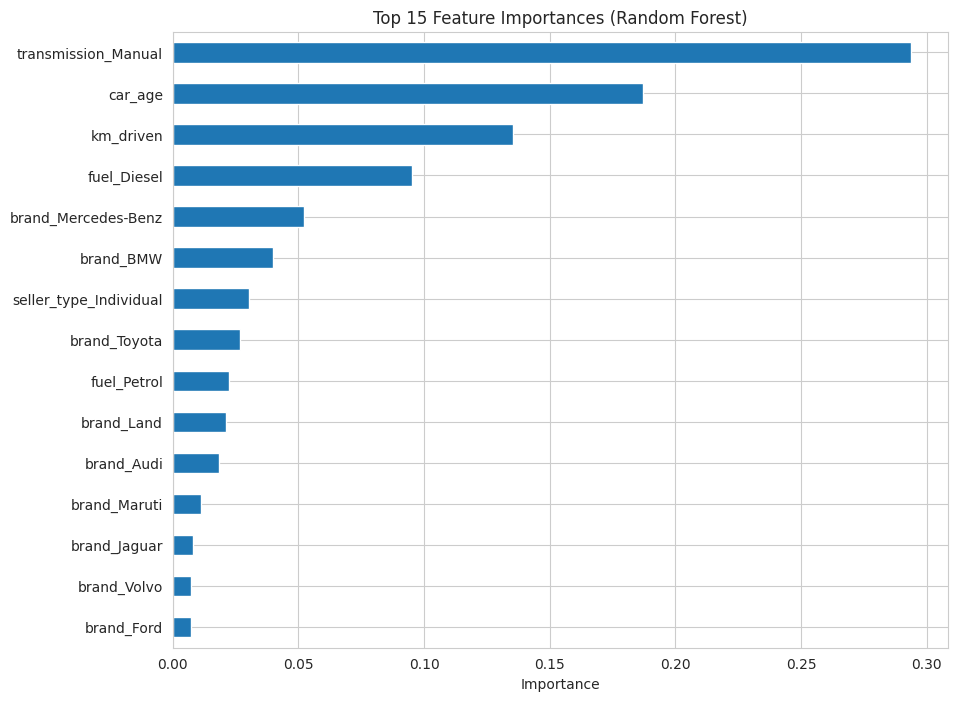

transmission_Manual       0.293764
car_age                   0.187056
km_driven                 0.135498
fuel_Diesel               0.095084
brand_Mercedes-Benz       0.052323
brand_BMW                 0.039668
seller_type_Individual    0.030241
brand_Toyota              0.026897
fuel_Petrol               0.022207
brand_Land                0.021179
brand_Audi                0.018476
brand_Maruti              0.011064
brand_Jaguar              0.007963
brand_Volvo               0.007319
brand_Ford                0.007172
dtype: float64


In [17]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

print(importances.head(15))

## 11. Residual Plot

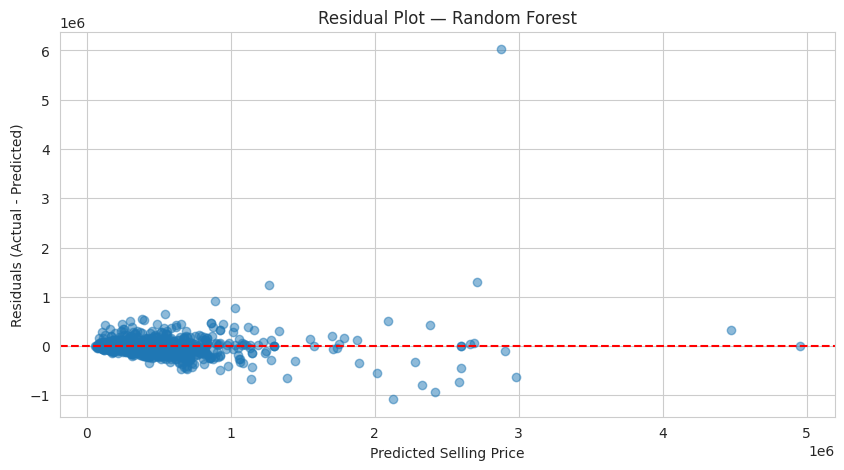

In [18]:
residuals = y_test - rf_preds

plt.figure(figsize=(10, 5))
plt.scatter(rf_preds, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot — Random Forest')
plt.xlabel('Predicted Selling Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

## Conclusion

**Best-performing model: Random Forest Regressor**

| Metric | Linear Regression | Random Forest |
|--------|-------------------|----------------|
| MAE    | 184,882.01        | 114,983.83     |
| RMSE   | 378,760.37        | 270,898.17     |
| R²     | 0.5299            | 0.7595         |

Random Forest outperformed Linear Regression across every metric, achieving a ~38% lower MAE and explaining ~76% of the variance in selling price versus ~53% for the linear model. This indicates car pricing depends on non-linear interactions between features that Linear Regression cannot capture.

**Key predictors:** `car_age` and `km_driven` were the strongest predictors of selling price, based on Random Forest feature importance.

**Residual analysis:** Residuals showed increasing spread at higher predicted prices, suggesting the model is less precise for expensive vehicles — likely due to fewer high-price examples in the training data.

**Limitations:** The dataset includes only basic listing attributes (no engine size, mileage rating, or condition), which likely caps achievable accuracy.